# Data Exploration
Importing necessary libraries and loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

motor_claims = pd.read_csv(r"C:\DS_Portfolio\GitHub\GLM_Pricing_French_MTPL\data\freMTPL2freq.csv")
print("Data Loaded Successfully")

Data Loaded Successfully


Shape of the dataset

In [2]:
print("Dataset Shape:")
print("Rows:", motor_claims.shape[0], ", Columns:", motor_claims.shape[1])

Dataset Shape:
Rows: 678013 , Columns: 12


Displaying the datatype info of the dataset

In [3]:
print(motor_claims.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  object 
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  object 
 9   VehGas      678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB
None


Tallying missing values

In [4]:
print("Missing value counts:")
print(motor_claims.isnull().sum())

Missing value counts:
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64


## Dataset Description

The **freMTPL2freq** dataset contains 12 columns with the following features:

| Column | Description |
|--------|-------------|
| **IDpol** | The policy ID (used to link with the claims dataset). |
| **ClaimNb** | Number of claims during the exposure period. |
| **Exposure** | The period of exposure for a policy, in years. |
| **VehPower** | The power of the car (ordered values). |
| **VehAge** | The vehicle age, in years. |
| **DrivAge** | The driver age, in years (in France, people can drive a car at 18). |
| **BonusMalus** | Bonus/malus, between 50 and 350: <100 means bonus, >100 means malus in France. |
| **VehBrand** | The car brand (unknown categories). |
| **VehGas** | The car gas, Diesel or regular. |
| **Area** | The density value of the city community where the car driver lives: from "A" for rural area to "F" for urban centre. |
| **Density** | The density of inhabitants (number of inhabitants per square-kilometer) of the city where the car driver lives. |
| **Region** | The policy region in France (based on the 1970-2015 classification). |

Diplaying the first few rows of the dataset to get an overview of the data structure and values.    

In [5]:
display(motor_claims.head())

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


Displaying summary statistics of the dataset to understand the distribution of numerical features and identify any potential outliers or anomalies.

In [6]:
display(motor_claims.describe(include='all'))

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
count,6.780130e+05,678013.000000,678013.000000,678013,678013.000000,678013.000000,678013.000000,678013.000000,678013,678013,678013.000000,678013
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22
top,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN,B12,Regular,NaN,R24
freq,NaN,NaN,NaN,191880,NaN,NaN,NaN,NaN,166024,345877,NaN,160601
mean,2.621857e+06,0.053247,0.528750,NaN,6.454631,7.044265,45.499122,59.761502,NaN,NaN,1792.422405,NaN
std,1.641783e+06,0.240117,0.364442,NaN,2.050906,5.666232,14.137444,15.636658,NaN,NaN,3958.646564,NaN
min,1.000000e+00,0.000000,0.002732,NaN,4.000000,0.000000,18.000000,50.000000,NaN,NaN,1.000000,NaN
25%,1.157951e+06,0.000000,0.180000,NaN,5.000000,2.000000,34.000000,50.000000,NaN,NaN,92.000000,NaN
50%,2.272152e+06,0.000000,0.490000,NaN,6.000000,6.000000,44.000000,50.000000,NaN,NaN,393.000000,NaN
75%,4.046274e+06,0.000000,0.990000,NaN,7.000000,11.000000,55.000000,64.000000,NaN,NaN,1658.000000,NaN


Target variable distribution: **ClaimNb** (number of claims) is the target variable for our frequency model. It is important to understand its distribution, as it is often highly skewed with policies with no claims.

ClaimNb value counts:


ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

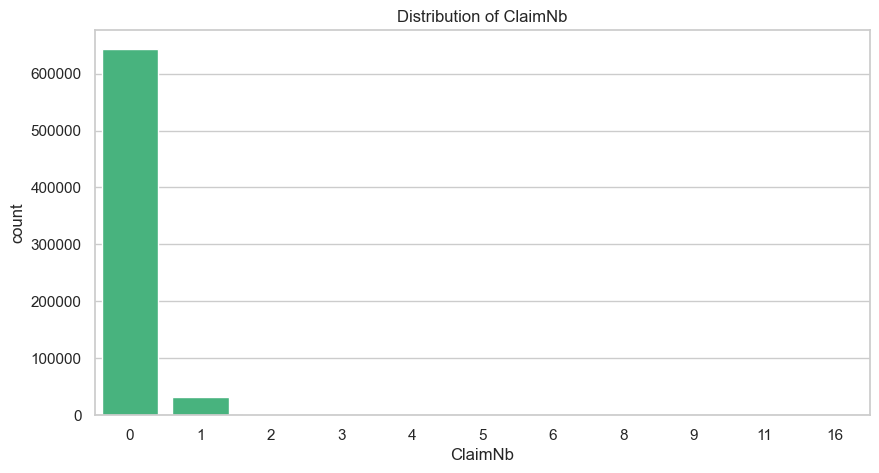

In [7]:
print("ClaimNb value counts:")
display(motor_claims['ClaimNb'].value_counts().sort_index())

# Setting theme for ClaimNb distribution
sns.set_theme(style="whitegrid", palette=sns.dark_palette("#36c57eb7", reverse=True))

plt.figure(figsize=(10, 5))
sns.countplot(data=motor_claims, x='ClaimNb')
plt.title('Distribution of ClaimNb')
plt.show()

Target variable distribution: **Exposure** (period of exposure in years) is a key variable that represents the time during which a policy is at risk. It is important to understand its distribution, as it can affect the frequency of claims and is often used as an offset in frequency models.

Exposure stats:
count    678013.000000
mean          0.528750
std           0.364442
min           0.002732
25%           0.180000
50%           0.490000
75%           0.990000
max           2.010000
Name: Exposure, dtype: float64


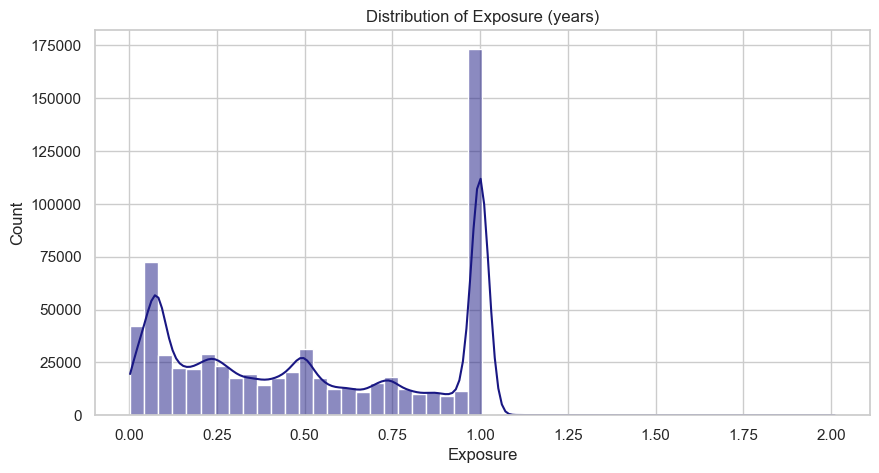

In [8]:
# Exposure
print("Exposure stats:")
print(motor_claims['Exposure'].describe())

# Changing colors for Exposure distribution
sns.set_theme(style="whitegrid", palette=sns.dark_palette("#19178392", reverse=True))

plt.figure(figsize=(10, 5))
sns.histplot(motor_claims['Exposure'], bins=50, kde=True)
plt.title('Distribution of Exposure (years)')
plt.show()



### Key Risk Factors
DrivAge, VehPower, VehAge, BonusMalus, Area, Density, Region

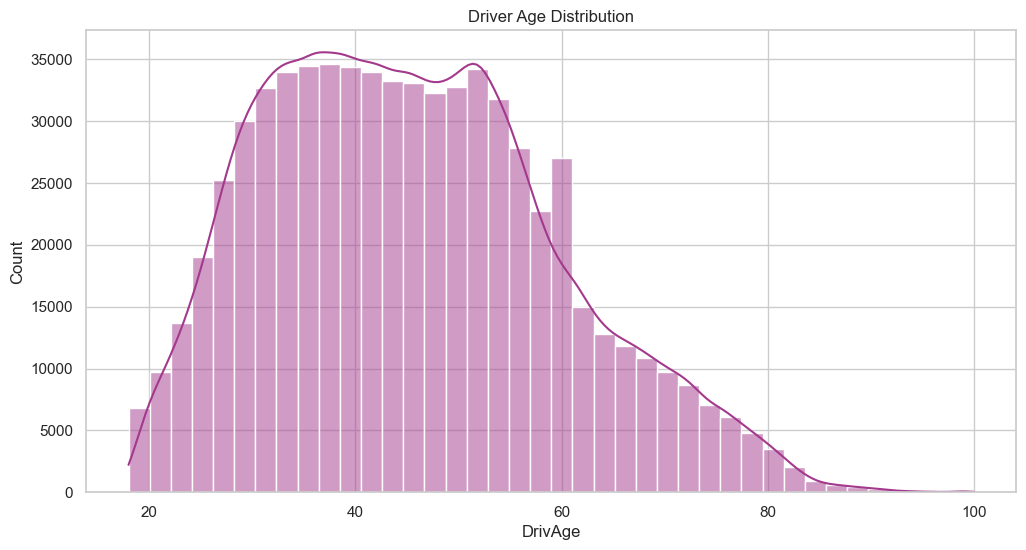

In [9]:
sns.set_palette(sns.dark_palette("#A3398C92", reverse=True))

# Driver age (expect higher risk at extremes)
plt.figure(figsize=(12, 6))
sns.histplot(motor_claims['DrivAge'], bins=40, kde=True)
plt.title('Driver Age Distribution')
plt.show()

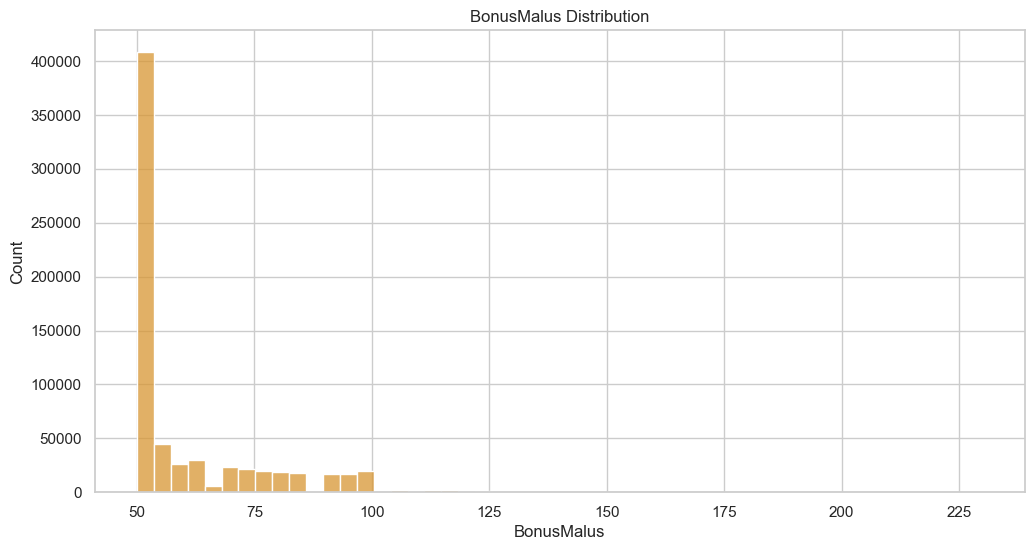

In [10]:
sns.set_palette(sns.dark_palette("#D8963392", reverse=True))

# BonusMalus (classic risk signal)
plt.figure(figsize=(12, 6))
sns.histplot(motor_claims['BonusMalus'], bins=50)
plt.title('BonusMalus Distribution')
plt.show()

In [11]:
# VehPower (often treated as categorical)
print("\nVehPower value counts:")
print(motor_claims['VehPower'].value_counts().sort_index())


VehPower value counts:
VehPower
4     115349
5     124821
6     148976
7     145401
8      46956
9      30085
10     31354
11     18352
12      8214
13      3229
14      2350
15      2926
Name: count, dtype: int64


In [12]:
# Area (A-F)
print("\nArea value counts:")
print(motor_claims['Area'].value_counts())


Area value counts:
Area
C    191880
D    151596
E    137167
A    103957
B     75459
F     17954
Name: count, dtype: int64


In [13]:
# Quick crosstab: Claim frequency by Area
freq_by_area = motor_claims.groupby('Area')['ClaimNb'].agg(['mean', 'count', 'sum'])
freq_by_area['empirical_freq'] = freq_by_area['sum'] / freq_by_area['count'] * 100  # per 100 policies
print("\nEmpirical claim frequency by Area (%):")
print(freq_by_area)


Empirical claim frequency by Area (%):
          mean   count   sum  empirical_freq
Area                                        
A     0.048703  103957  5063        4.870283
B     0.050358   75459  3800        5.035847
C     0.051464  191880  9875        5.146446
D     0.055595  151596  8428        5.559513
E     0.056901  137167  7805        5.690144
F     0.062994   17954  1131        6.299432


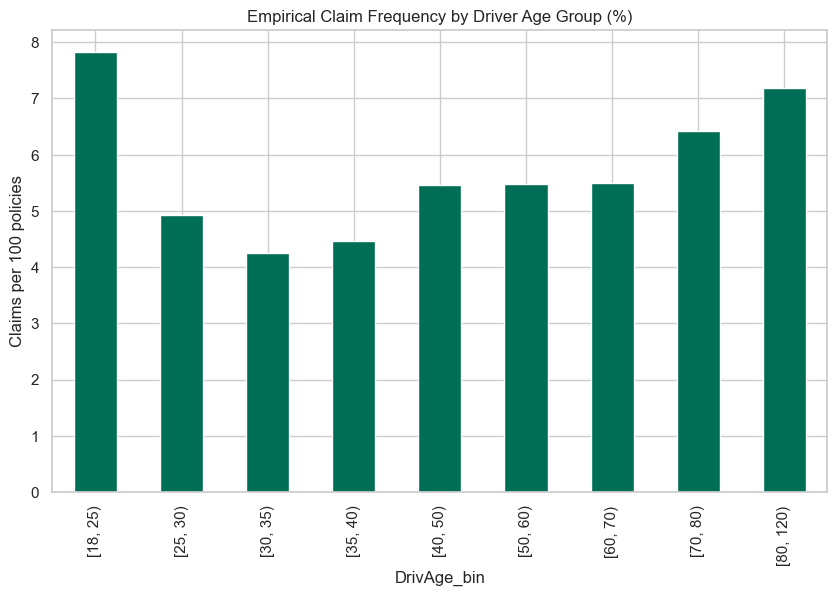

In [14]:
sns.set_palette(sns.dark_palette("#006D556C", reverse=True))

# Same for DrivAge – bin it for visualization
motor_claims['DrivAge_bin'] = pd.cut(motor_claims['DrivAge'], bins=[18,25,30,35,40,50,60,70,80,120], right=False)
freq_by_age = motor_claims.groupby('DrivAge_bin', observed=False)['ClaimNb'].mean() * 100  # % frequency
freq_by_age.plot(kind='bar', figsize=(10,6), title='Empirical Claim Frequency by Driver Age Group (%)')
plt.ylabel('Claims per 100 policies')
plt.show()

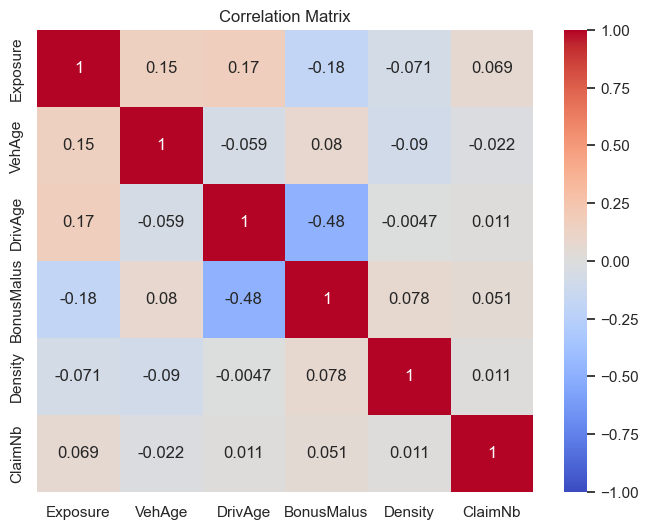

In [15]:
sns.set_palette(sns.dark_palette("#0092BEC0", reverse=True))

# Correlation heatmap (numerical vars only)
num_cols = ['Exposure', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'ClaimNb']
corr = motor_claims[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()